Can we predict whether a customer is likely to churn based on their characteristics?

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
from scipy.stats import fisher_exact
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [25]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(7043, 21)
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod

In [4]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print("Missing TotalCharges:", df["TotalCharges"].isna().sum())

Missing TotalCharges: 11


In [4]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

print("Missing TotalCharges after cleaning:", df["TotalCharges"].isna().sum())
print("TotalCharges dtype:", df["TotalCharges"].dtype)

Missing TotalCharges after cleaning: 0
TotalCharges dtype: float64


In [5]:
df["ChurnFlag"] = (df["Churn"] == "Yes").astype(int)

print(df["ChurnFlag"].value_counts())
print(df["ChurnFlag"].value_counts(normalize=True) * 100)

ChurnFlag
0    5174
1    1869
Name: count, dtype: int64
ChurnFlag
0    73.463013
1    26.536987
Name: proportion, dtype: float64


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [9]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5634, 19)
X_test: (1409, 19)
y_train: (5634,)
y_test: (1409,)


In [10]:
numeric_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

categorical_features = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Total features:", len(numeric_features) + len(categorical_features))

Numerical features: 4
Categorical features: 15
Total features: 19


In [12]:
print("Training churn rate:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest churn rate:")
print(y_test.value_counts(normalize=True) * 100)

Training churn rate:
ChurnFlag
0    73.464679
1    26.535321
Name: proportion, dtype: float64

Test churn rate:
ChurnFlag
0    73.456352
1    26.543648
Name: proportion, dtype: float64


In [16]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_features
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(
                    drop="first",
                    handle_unknown="ignore"
                ))
            ]),
            categorical_features
        )
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


LOGISTIC REGRESSION

In [17]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

print("Logistic Regression pipeline created successfully.")

Logistic Regression pipeline created successfully.


In [18]:
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [19]:
y_pred = logistic_model.predict(X_test)

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred))

Predictions generated successfully.
Number of predictions: 1409


In [21]:
print(y_pred[:20])

[0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0]


In [26]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[926 109]
 [165 209]]


In [28]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.8055358410220014
Precision: 0.6572327044025157
Recall   : 0.5588235294117647
F1 Score : 0.6040462427745664


In [30]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [32]:


y_prob = logistic_model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.8420083184789068


The Logistic Regression baseline achieves 81% accuracy, but its 56% recall for churn indicates that a substantial proportion of at-risk customers are not being identified. Therefore, improving churn detection should be a priority.

DECISION TREE

In [38]:
categorical_cols = X_train.select_dtypes(include=["str", "object"]).columns
numerical_cols = X_train.select_dtypes(exclude=["str", "object"]).columns

print("Categorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numerical_cols)

Categorical columns:
Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='str')

Numerical columns:
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='str')


In [39]:
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X_train_cat = encoder.fit_transform(X_train[categorical_cols])
X_test_cat = encoder.transform(X_test[categorical_cols])

In [40]:
X_train_encoded = pd.DataFrame(
    X_train_cat,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=X_train.index
)

X_test_encoded = pd.DataFrame(
    X_test_cat,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=X_test.index
)

X_train_final = pd.concat(
    [X_train[numerical_cols], X_train_encoded],
    axis=1
)

X_test_final = pd.concat(
    [X_test[numerical_cols], X_test_encoded],
    axis=1
)

print("X_train shape:", X_train_final.shape)
print("X_test shape:", X_test_final.shape)

X_train shape: (5634, 45)
X_test shape: (1409, 45)


In [41]:
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

dt_model.fit(X_train_final, y_train)

dt_pred = dt_model.predict(X_test_final)

print("Decision Tree predictions generated:", len(dt_pred))

Decision Tree predictions generated: 1409


In [42]:
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.85      0.88      0.87      1035
           1       0.63      0.57      0.60       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [43]:
dt_prob = dt_model.predict_proba(X_test_final)[:, 1]

print("ROC-AUC Score:", roc_auc_score(y_test, dt_prob))

ROC-AUC Score: 0.830278488206877


After comparing Logic Regression model and Decision Tree model we conclude that Logistic Regression is currently the better model overall

RANDOM FOREST

In [46]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=8
)

rf_model.fit(X_train_final, y_train)

rf_pred = rf_model.predict(X_test_final)

print("Random Forest predictions generated:", len(rf_pred))

Random Forest predictions generated: 1409


In [47]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.84      0.91      0.88      1035
           1       0.69      0.52      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



In [49]:
rf_prob = rf_model.predict_proba(X_test_final)[:, 1]

print("ROC-AUC Score:", roc_auc_score(y_test, rf_prob))

ROC-AUC Score: 0.8416143532511818


After comparing all three models 

Random Forest has the highest churn precision (69%), meaning when it says a customer will churn, it's more often correct
But its recall is only 52%. It misses more actual churners than Logistic Regression
And its ROC-AUC (0.8416) is essentially the same as Logistic Regression (0.8420)

Logistic Regression remains our best overall model.

GRADIENT BOOSTING

In [54]:
print("Missing values in X_train_final:")
print(X_train_final.isna().sum()[X_train_final.isna().sum() > 0])

print("\nMissing values in X_test_final:")
print(X_test_final.isna().sum()[X_test_final.isna().sum() > 0])

Missing values in X_train_final:
TotalCharges    8
dtype: int64

Missing values in X_test_final:
TotalCharges    3
dtype: int64


In [56]:
imputer = SimpleImputer(strategy="median")

X_train_final = pd.DataFrame(
    imputer.fit_transform(X_train_final),
    columns=X_train_final.columns,
    index=X_train_final.index
)

X_test_final = pd.DataFrame(
    imputer.transform(X_test_final),
    columns=X_test_final.columns,
    index=X_test_final.index
)

In [57]:
imputer.fit_transform(X_train_final)

array([[  0.  ,  35.  ,  49.2 , ...,   0.  ,   1.  ,   0.  ],
       [  0.  ,  15.  ,  75.1 , ...,   0.  ,   0.  ,   1.  ],
       [  0.  ,  13.  ,  40.55, ...,   0.  ,   0.  ,   1.  ],
       ...,
       [  1.  ,  25.  , 102.8 , ...,   0.  ,   0.  ,   1.  ],
       [  0.  ,  24.  ,  20.4 , ...,   1.  ,   0.  ,   0.  ],
       [  0.  ,   6.  ,  20.65, ...,   0.  ,   0.  ,   1.  ]],
      shape=(5634, 45))

In [58]:
imputer.transform(X_test_final)

array([[  0.  ,  72.  , 114.05, ...,   1.  ,   0.  ,   0.  ],
       [  1.  ,   8.  , 100.15, ...,   1.  ,   0.  ,   0.  ],
       [  0.  ,  41.  ,  78.35, ...,   1.  ,   0.  ,   0.  ],
       ...,
       [  0.  ,   5.  ,  20.65, ...,   0.  ,   0.  ,   0.  ],
       [  0.  ,  56.  ,  19.7 , ...,   0.  ,   0.  ,   0.  ],
       [  0.  ,  72.  ,  70.45, ...,   0.  ,   0.  ,   0.  ]],
      shape=(1409, 45))

In [59]:
print("Training missing values:", X_train_final.isna().sum().sum())
print("Testing missing values:", X_test_final.isna().sum().sum())

Training missing values: 0
Testing missing values: 0


In [60]:
gb_model.fit(X_train_final, y_train)

gb_pred = gb_model.predict(X_test_final)

print("Gradient Boosting predictions generated:", len(gb_pred))

Gradient Boosting predictions generated: 1409


In [61]:
print(classification_report(y_test, gb_pred))

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [62]:
gb_prob = gb_model.predict_proba(X_test_final)[:, 1]

print("ROC-AUC Score:", roc_auc_score(y_test, gb_prob))

ROC-AUC Score: 0.8431734222015552


| Model                   | Accuracy | Churn Precision | Churn Recall | Churn F1 |    ROC-AUC |
| ----------------------- | -------: | --------------: | -----------: | -------: | ---------: |
| **Logistic Regression** |  **81%** |             66% |          56% |  **60%** |     0.8420 |
| Decision Tree           |      80% |             63% |      **57%** |  **60%** |     0.8303 |
| Random Forest           |  **81%** |         **69%** |          52% |      59% |     0.8416 |
| **Gradient Boosting**   |      80% |             66% |          52% |      58% | **0.8432** |


Logistic Regression as the baseline/best current model, because it gives a good balance of accuracy, precision, recall, F1, and ROC-AUC while also being highly interpretable.

But still churn recall is only 56%. For a retention team, those 165 missed customers could be valuable.

In [64]:
y_prob = logistic_model.predict_proba(X_test)[:, 1]

print(y_prob[:20])

[0.04547351 0.68469189 0.05977168 0.39990202 0.0215752  0.60314467
 0.44879448 0.12908887 0.00291363 0.3954711  0.26476788 0.06254598
 0.12972982 0.68589889 0.12797672 0.05831677 0.03295405 0.63723881
 0.18084428 0.08547657]


In [65]:
thresholds = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]

for threshold in thresholds:
    
    y_threshold = (y_prob >= threshold).astype(int)
    
    precision = precision_score(y_test, y_threshold)
    recall = recall_score(y_test, y_threshold)
    f1 = f1_score(y_test, y_threshold)
    
    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.2f} | "
        f"Recall: {recall:.2f} | "
        f"F1: {f1:.2f}"
    )

Threshold: 0.30 | Precision: 0.52 | Recall: 0.75 | F1: 0.62
Threshold: 0.35 | Precision: 0.54 | Recall: 0.71 | F1: 0.61
Threshold: 0.40 | Precision: 0.57 | Recall: 0.67 | F1: 0.62
Threshold: 0.45 | Precision: 0.60 | Recall: 0.61 | F1: 0.61
Threshold: 0.50 | Precision: 0.66 | Recall: 0.56 | F1: 0.60
Threshold: 0.55 | Precision: 0.68 | Recall: 0.46 | F1: 0.55
Threshold: 0.60 | Precision: 0.72 | Recall: 0.40 | F1: 0.51


In [66]:
optimal_threshold = 0.40

y_pred_optimized = (y_prob >= optimal_threshold).astype(int)

print("Optimized predictions generated.")

Optimized predictions generated.


In [67]:
print(classification_report(y_test, y_pred_optimized))

              precision    recall  f1-score   support

           0       0.87      0.82      0.84      1035
           1       0.57      0.67      0.62       374

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.78      1409



In [68]:
cm_optimized = confusion_matrix(y_test, y_pred_optimized)

print(cm_optimized)

[[847 188]
 [124 250]]


In [69]:
y_pred = logistic_model.predict(X_test)

Model Interpretation

In [71]:
print(logistic_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                           

In [72]:
print(logistic_model.named_steps.keys())

dict_keys(['preprocessor', 'classifier'])


In [73]:
# Get the preprocessing and Logistic Regression steps
preprocessor = logistic_model.named_steps["preprocessor"]
classifier = logistic_model.named_steps["classifier"]

# Get the feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Get Logistic Regression coefficients
coefficients = classifier.coef_[0]

# Create a dataframe
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Absolute coefficient = strength of relationship
feature_importance["Abs_Coefficient"] = feature_importance["Coefficient"].abs()

# Sort by strongest features
feature_importance = feature_importance.sort_values(
    "Abs_Coefficient",
    ascending=False
)

feature_importance.head(20)

,Feature,Coefficient,Abs_Coefficient
25,cat__Contract_Two year,-1.330231,1.330231
1,num__tenure,-1.242410,1.242410
10,cat__InternetService_Fiber optic,1.199218,1.199218
24,cat__Contract_One year,-0.687826,0.687826
3,num__TotalCharges,0.513253,0.513253
7,cat__PhoneService_Yes,-0.501653,0.501653
2,num__MonthlyCharges,-0.484668,0.484668
21,cat__StreamingTV_Yes,0.383225,0.383225
23,cat__StreamingMovies_Yes,0.382622,0.382622
28,cat__PaymentMethod_Electronic check,0.381086,0.381086


In [75]:
top_churn_drivers = (
    feature_importance[
        feature_importance["Coefficient"] > 0
    ]
    .sort_values("Coefficient", ascending=False)
    .head(10)
)

top_churn_drivers

,Feature,Coefficient,Abs_Coefficient,Odds_Ratio
10,cat__InternetService_Fiber optic,1.199218,1.199218,3.317522
3,num__TotalCharges,0.513253,0.513253,1.670717
21,cat__StreamingTV_Yes,0.383225,0.383225,1.467008
23,cat__StreamingMovies_Yes,0.382622,0.382622,1.466124
28,cat__PaymentMethod_Electronic check,0.381086,0.381086,1.463873
26,cat__PaperlessBilling_Yes,0.372843,0.372843,1.451856
9,cat__MultipleLines_Yes,0.364750,0.364750,1.440154
29,cat__PaymentMethod_Mailed check,0.072377,0.072377,1.075061
0,num__SeniorCitizen,0.054617,0.054617,1.056136
17,cat__DeviceProtection_Yes,0.037983,0.037983,1.038714


In [76]:
top_retention_factors = (
    feature_importance[
        feature_importance["Coefficient"] < 0
    ]
    .sort_values("Coefficient")
    .head(10)
)

top_retention_factors

,Feature,Coefficient,Abs_Coefficient,Odds_Ratio
25,cat__Contract_Two year,-1.330231,1.330231,0.264416
1,num__tenure,-1.242410,1.242410,0.288688
24,cat__Contract_One year,-0.687826,0.687826,0.502667
7,cat__PhoneService_Yes,-0.501653,0.501653,0.605529
2,num__MonthlyCharges,-0.484668,0.484668,0.615902
13,cat__OnlineSecurity_Yes,-0.346154,0.346154,0.707404
19,cat__TechSupport_Yes,-0.294050,0.294050,0.745239
8,cat__MultipleLines_No phone service,-0.264058,0.264058,0.767929
6,cat__Dependents_Yes,-0.227626,0.227626,0.796422
16,cat__DeviceProtection_No internet service,-0.174643,0.174643,0.839757


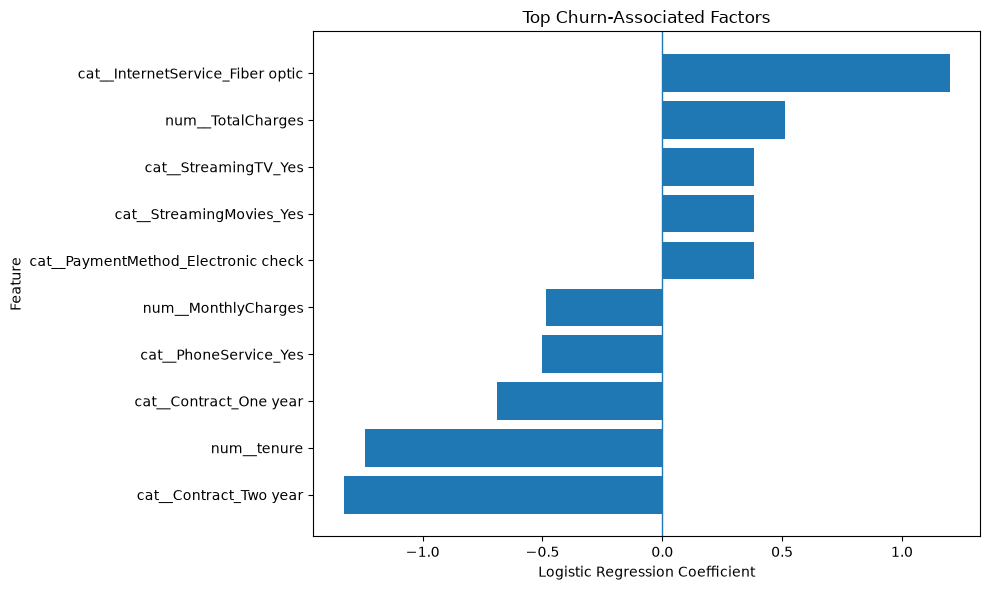

In [77]:
# Select top 10 features by absolute coefficient
top_features = feature_importance.head(10).copy()

# Sort for plotting
top_features = top_features.sort_values("Coefficient")

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.axvline(0, linewidth=1)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Top Churn-Associated Factors")

plt.tight_layout()
plt.show()

In [78]:
churn_probability = logistic_model.predict_proba(X_test)[:, 1]

customer_predictions = X_test.copy()

customer_predictions["Actual_Churn"] = y_test
customer_predictions["Churn_Probability"] = churn_probability

customer_predictions.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Actual_Churn,Churn_Probability
437,Male,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,Yes,...,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),114.05,8468.20,0,0.045474
2280,Female,1,No,No,8,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Yes,Month-to-month,Yes,Credit card (automatic),100.15,908.55,0,0.684692
2235,Female,0,Yes,Yes,41,Yes,Yes,DSL,Yes,Yes,...,No,Yes,No,One year,Yes,Credit card (automatic),78.35,3211.20,0,0.059772
4460,Male,0,Yes,No,18,Yes,No,Fiber optic,No,No,...,Yes,No,No,Month-to-month,No,Electronic check,78.20,1468.75,0,0.399902
3761,Female,0,Yes,No,72,Yes,Yes,DSL,Yes,Yes,...,No,Yes,Yes,Two year,Yes,Credit card (automatic),82.65,5919.35,0,0.021575


In [88]:
customer_predictions.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Actual_Churn,Churn_Probability,Predicted_Churn
437,Male,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,Yes,...,Yes,Yes,Two year,Yes,Credit card (automatic),114.05,8468.20,0,0.045474,0
2280,Female,1,No,No,8,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Credit card (automatic),100.15,908.55,0,0.684692,1
2235,Female,0,Yes,Yes,41,Yes,Yes,DSL,Yes,Yes,...,Yes,No,One year,Yes,Credit card (automatic),78.35,3211.20,0,0.059772,0
4460,Male,0,Yes,No,18,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,No,Electronic check,78.20,1468.75,0,0.399902,0
3761,Female,0,Yes,No,72,Yes,Yes,DSL,Yes,Yes,...,Yes,Yes,Two year,Yes,Credit card (automatic),82.65,5919.35,0,0.021575,0


In [89]:
customer_predictions.columns.tolist()

['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Actual_Churn',
 'Churn_Probability',
 'Predicted_Churn']

In [90]:
optimal_threshold = 0.4

In [91]:
cm_optimized = confusion_matrix(
    customer_predictions["Actual_Churn"],
    customer_predictions["Predicted_Churn"]
)

print("Confusion Matrix:")
print(cm_optimized)

print("\nClassification Report:")
print(
    classification_report(
        customer_predictions["Actual_Churn"],
        customer_predictions["Predicted_Churn"]
    )
)

Confusion Matrix:
[[847 188]
 [124 250]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.82      0.84      1035
           1       0.57      0.67      0.62       374

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.78      1409



In [92]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "ROC_AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, dt_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, gb_prob)
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, gb_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, gb_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, gb_pred)
    ],
    "F1": [
        f1_score(y_test, y_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, gb_pred)
    ]
})

model_comparison.sort_values("ROC_AUC", ascending=False)

,Model,ROC_AUC,Accuracy,Precision,Recall,F1
3,Gradient Boosting,0.843173,0.802697,0.664384,0.518717,0.582583
0,Logistic Regression,0.842008,0.805536,0.657233,0.558824,0.604046
2,Random Forest,0.841614,0.809084,0.686833,0.516043,0.589313
1,Decision Tree,0.830278,0.798439,0.634731,0.566845,0.598870


In [93]:
customer_predictions["Risk_Segment"] = pd.cut(
    customer_predictions["Churn_Probability"],
    bins=[0, 0.4, 0.7, 1],
    labels=["Low Risk", "Medium Risk", "High Risk"],
    include_lowest=True
)

customer_predictions["Risk_Segment"].value_counts()

Risk_Segment
Low Risk       971
Medium Risk    346
High Risk       92
Name: count, dtype: int64

In [94]:
high_risk = customer_predictions[
    customer_predictions["Risk_Segment"] == "High Risk"
]

print("High-risk customers:", len(high_risk))

high_risk.head()

High-risk customers: 92


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Actual_Churn,Churn_Probability,Predicted_Churn,Risk_Segment
6529,Male,1,No,No,2,Yes,Yes,Fiber optic,No,No,...,No,Month-to-month,Yes,Mailed check,74.85,156.40,1,0.725479,1,High Risk
5547,Female,0,No,No,3,Yes,No,Fiber optic,No,No,...,Yes,Month-to-month,Yes,Electronic check,89.45,240.45,1,0.776260,1,High Risk
346,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,Yes,Month-to-month,Yes,Electronic check,90.40,168.20,1,0.779545,1,High Risk
6633,Female,0,No,No,1,Yes,Yes,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,74.50,74.50,1,0.758980,1,High Risk
2519,Male,0,Yes,No,2,Yes,Yes,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,91.45,171.45,0,0.787968,1,High Risk


In [95]:
print("Contract:")
print(high_risk["Contract"].value_counts())

print("\nInternet Service:")
print(high_risk["InternetService"].value_counts())

print("\nPayment Method:")
print(high_risk["PaymentMethod"].value_counts())

print("\nOnline Security:")
print(high_risk["OnlineSecurity"].value_counts())

print("\nTech Support:")
print(high_risk["TechSupport"].value_counts())

Contract:
Contract
Month-to-month    92
Name: count, dtype: int64

Internet Service:
InternetService
Fiber optic    90
DSL             2
Name: count, dtype: int64

Payment Method:
PaymentMethod
Electronic check             82
Mailed check                  4
Bank transfer (automatic)     4
Credit card (automatic)       2
Name: count, dtype: int64

Online Security:
OnlineSecurity
No     91
Yes     1
Name: count, dtype: int64

Tech Support:
TechSupport
No     90
Yes     2
Name: count, dtype: int64


In [97]:
high_risk[
    ["tenure", "MonthlyCharges", "TotalCharges", "Churn_Probability"]
].describe().round(2)

,tenure,MonthlyCharges,TotalCharges,Churn_Probability
count,92.00,92.00,92.00,92.00
mean,5.58,84.66,500.69,0.75
std,5.55,12.64,551.04,0.04
min,1.00,41.15,69.10,0.70
25%,1.75,75.18,113.10,0.72
50%,3.50,84.72,304.88,0.74
75%,8.00,94.64,700.96,0.78
max,26.00,111.40,2515.30,0.86


For a new customer, the trained model calculates the probability that the customer will churn. If the probability is ≥ 0.4, we classify the customer as high-risk for churn.

In [98]:
# Take one unseen customer from the test set
new_customer = X_test.iloc[[0]].copy()

# Predict probability of churn
churn_probability = logistic_model.predict_proba(new_customer)[0, 1]

# Apply our chosen threshold
predicted_churn = int(churn_probability >= 0.4)

print("Churn Probability:", round(churn_probability, 2))
print("Predicted Churn:", predicted_churn)

Churn Probability: 0.05
Predicted Churn: 0


Check whether a new customer is at what level of risk that they will churn 

In [100]:
X.columns.tolist()

['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges']

In [104]:
new_customer = pd.DataFrame([{
    "gender": "Female",
    "SeniorCitizen": 0,
    "Partner": "No",
    "Dependents": "No",
    "tenure": 3,
    "PhoneService": "Yes",
    "MultipleLines": "No",
    "InternetService": "Fiber optic",
    "OnlineSecurity": "No",
    "OnlineBackup": "No",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "Yes",
    "StreamingMovies": "Yes",
    "Contract": "Two year",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 85.00,
    "TotalCharges": 255.00
}])

In [108]:
result = new_customer.copy()

result["Churn_Probability"] = churn_probability
result["Risk_Segment"] = risk_segment

result[["tenure", "Contract", "InternetService",
        "PaymentMethod", "MonthlyCharges",
        "Churn_Probability", "Risk_Segment"]]

,tenure,Contract,InternetService,PaymentMethod,MonthlyCharges,Churn_Probability,Risk_Segment
0,3,Two year,Fiber optic,Electronic check,85.0,0.497155,Medium Risk
